# Daily Challenge - Statistics for Machine Learning
## Building a Predictive Model for Customer Churn

# Part 1: Exploratory Data Analysis & Inferential Statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")
sns.set_context("poster")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load data
df = pd.read_csv('Churn_Modelling.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst rows:")
df.head()

Dataset shape: (10000, 14)

First rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Data info
print("\nData Info:")
print(df.info())
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nChurn distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn rate: {df['Exited'].mean()*100:.2f}%")


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB
None

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore 

## Statistical Analysis Summary

In [4]:
# Split by Exited status
df_stayed = df[df['Exited'] == 0]
df_left = df[df['Exited'] == 1]

# Statistical tests for key features
features_to_test = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']
results = {}

for feature in features_to_test:
    t_stat, p_value = ttest_ind(df_left[feature], df_stayed[feature])
    results[feature] = {
        'stayed_mean': df_stayed[feature].mean(),
        'left_mean': df_left[feature].mean(),
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }

# Display results
print("\nHypothesis Tests (t-test):")
print("="*70)
for feature, stats in results.items():
    sig = "✓ SIGNIFICANT" if stats['significant'] else "✗ NOT SIGNIFICANT"
    print(f"\n{feature}:")
    print(f"  Stayed mean: {stats['stayed_mean']:.2f} | Left mean: {stats['left_mean']:.2f}")
    print(f"  p-value: {stats['p_value']:.6f} {sig}")


Hypothesis Tests (t-test):

Age:
  Stayed mean: 37.41 | Left mean: 44.84
  p-value: 0.000000 ✓ SIGNIFICANT

CreditScore:
  Stayed mean: 651.85 | Left mean: 645.35
  p-value: 0.006738 ✓ SIGNIFICANT

Balance:
  Stayed mean: 72745.30 | Left mean: 91108.54
  p-value: 0.000000 ✓ SIGNIFICANT

EstimatedSalary:
  Stayed mean: 99738.39 | Left mean: 101465.68
  p-value: 0.226440 ✗ NOT SIGNIFICANT


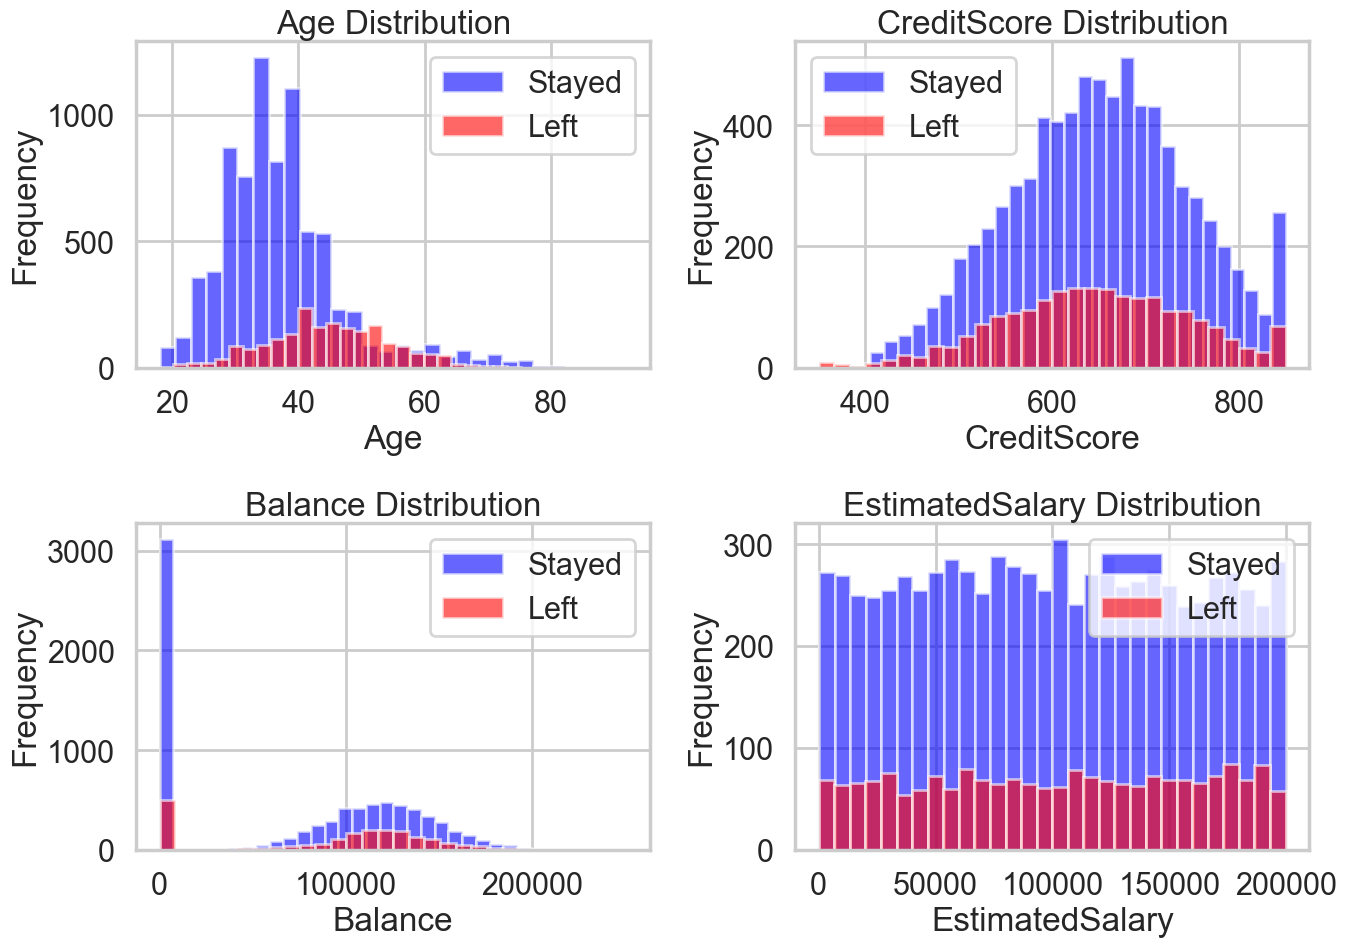

Age and Balance show the strongest differences between groups.


In [5]:
# Visualize key distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features_to_test):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df_stayed[feature], bins=30, alpha=0.6, label='Stayed', color='blue')
    ax.hist(df_left[feature], bins=30, alpha=0.6, label='Left', color='red')
    ax.set_title(f'{feature} Distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

print("Age and Balance show the strongest differences between groups.")

# Part 2: Data Preprocessing

In [6]:
# Create a copy for preprocessing
df_model = df.copy()

# Drop unnecessary columns
df_model = df_model.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print(f"Columns before encoding: {df_model.columns.tolist()}")
print(f"Data shape: {df_model.shape}")

Columns before encoding: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Data shape: (10000, 11)


In [7]:
# Encode categorical features
# Method: One-hot encoding for Geography and Gender
df_model = pd.get_dummies(df_model, columns=['Geography', 'Gender'], drop_first=True)

print(f"Columns after encoding:")
print(df_model.columns.tolist())
print(f"\nData shape after encoding: {df_model.shape}")
print(f"\nData types:")
print(df_model.dtypes)

Columns after encoding:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Data shape after encoding: (10000, 12)

Data types:
CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object


In [8]:
# Check final processed data
print("Processed data sample:")
df_model.head()

Processed data sample:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [9]:
# Separate features and target
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:")
print(X.columns.tolist())

Features shape: (10000, 11)
Target shape: (10000,)

Feature columns:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [10]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")

Training set size: 8000
Test set size: 2000

Training churn rate: 20.38%
Test churn rate: 20.35%


In [11]:
# Feature Scaling - important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")
print(f"Train mean: {X_train_scaled.mean():.4f}")
print(f"Train std: {X_train_scaled.std():.4f}")

Features scaled successfully
Train mean: -0.0000
Train std: 1.0000


# Part 3: Model Training

In [12]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Train models
trained_models = {}

print("Training models...\n")
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✓ {name} trained")

print("\nAll models trained successfully!")

Training models...

✓ Logistic Regression trained
✓ Random Forest trained

All models trained successfully!


# Part 4: Model Evaluation

In [13]:
# Make predictions and evaluate
evaluation_results = {}

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    evaluation_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

print("Predictions completed!")

Predictions completed!


In [14]:
# Display evaluation results
print("\n" + "="*80)
print("MODEL EVALUATION RESULTS")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': list(evaluation_results.keys()),
    'Accuracy': [evaluation_results[m]['accuracy'] for m in evaluation_results.keys()],
    'Precision': [evaluation_results[m]['precision'] for m in evaluation_results.keys()],
    'Recall': [evaluation_results[m]['recall'] for m in evaluation_results.keys()],
    'F1-Score': [evaluation_results[m]['f1'] for m in evaluation_results.keys()],
    'ROC-AUC': [evaluation_results[m]['roc_auc'] for m in evaluation_results.keys()]
})

print(comparison_df.to_string(index=False))
print("\n" + "="*80)


MODEL EVALUATION RESULTS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression    0.8080   0.589147 0.186732  0.283582 0.774778
      Random Forest    0.8645   0.783333 0.461916  0.581144 0.852629



In [15]:
# Detailed metrics for each model
for name in evaluation_results.keys():
    print(f"\n{name}:")
    print("-" * 50)
    print(f"Accuracy:  {evaluation_results[name]['accuracy']:.4f}")
    print(f"Precision: {evaluation_results[name]['precision']:.4f}")
    print(f"Recall:    {evaluation_results[name]['recall']:.4f}")
    print(f"F1-Score:  {evaluation_results[name]['f1']:.4f}")
    print(f"ROC-AUC:   {evaluation_results[name]['roc_auc']:.4f}")


Logistic Regression:
--------------------------------------------------
Accuracy:  0.8080
Precision: 0.5891
Recall:    0.1867
F1-Score:  0.2836
ROC-AUC:   0.7748

Random Forest:
--------------------------------------------------
Accuracy:  0.8645
Precision: 0.7833
Recall:    0.4619
F1-Score:  0.5811
ROC-AUC:   0.8526



Logistic Regression - Confusion Matrix:
  True Negatives:  1540
  False Positives: 53
  False Negatives: 331
  True Positives:  76

Random Forest - Confusion Matrix:
  True Negatives:  1541
  False Positives: 52
  False Negatives: 219
  True Positives:  188


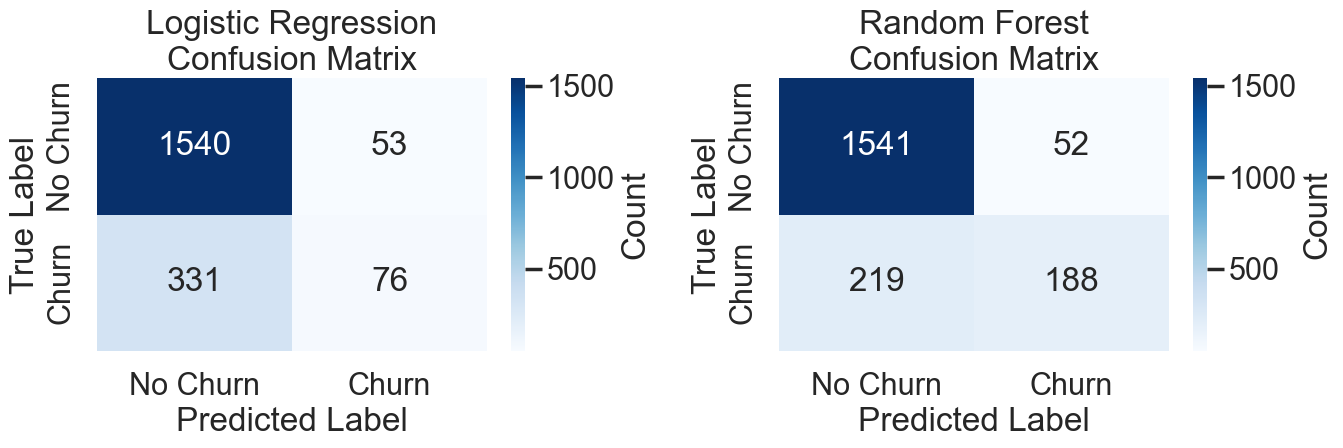

In [16]:
# Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = evaluation_results[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                cbar_kws={'label': 'Count'})
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
    # Print interpretation
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name} - Confusion Matrix:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")

plt.tight_layout()
plt.show()

In [17]:
# Detailed Classification Report
for name in evaluation_results.keys():
    print(f"\n{'='*60}")
    print(f"Classification Report - {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, evaluation_results[name]['y_pred'], 
                                target_names=['No Churn', 'Churn']))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.82      0.97      0.89      1593
       Churn       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


Classification Report - Random Forest
              precision    recall  f1-score   support

    No Churn       0.88      0.97      0.92      1593
       Churn       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



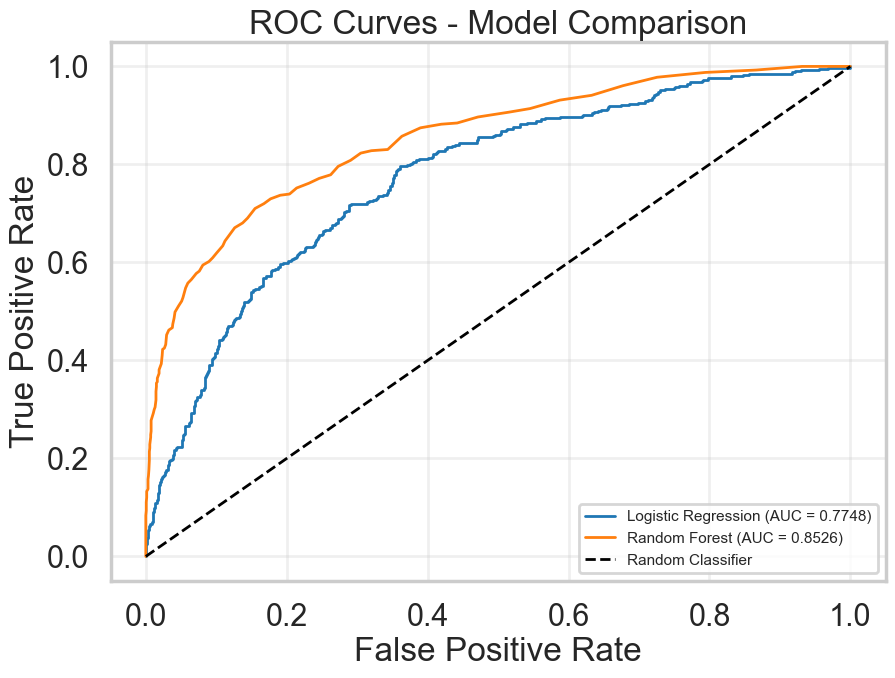

In [18]:
# ROC Curves
plt.figure(figsize=(10, 7))

for name in evaluation_results.keys():
    fpr, tpr, _ = roc_curve(y_test, evaluation_results[name]['y_pred_proba'])
    auc = evaluation_results[name]['roc_auc']
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# Part 5: Feature Importance Analysis


Top 10 Most Important Features (Random Forest):
          Feature  Importance
              Age    0.236485
  EstimatedSalary    0.147016
      CreditScore    0.142756
          Balance    0.141756
    NumOfProducts    0.130410
           Tenure    0.081817
   IsActiveMember    0.039933
Geography_Germany    0.028923
        HasCrCard    0.018799
      Gender_Male    0.018483


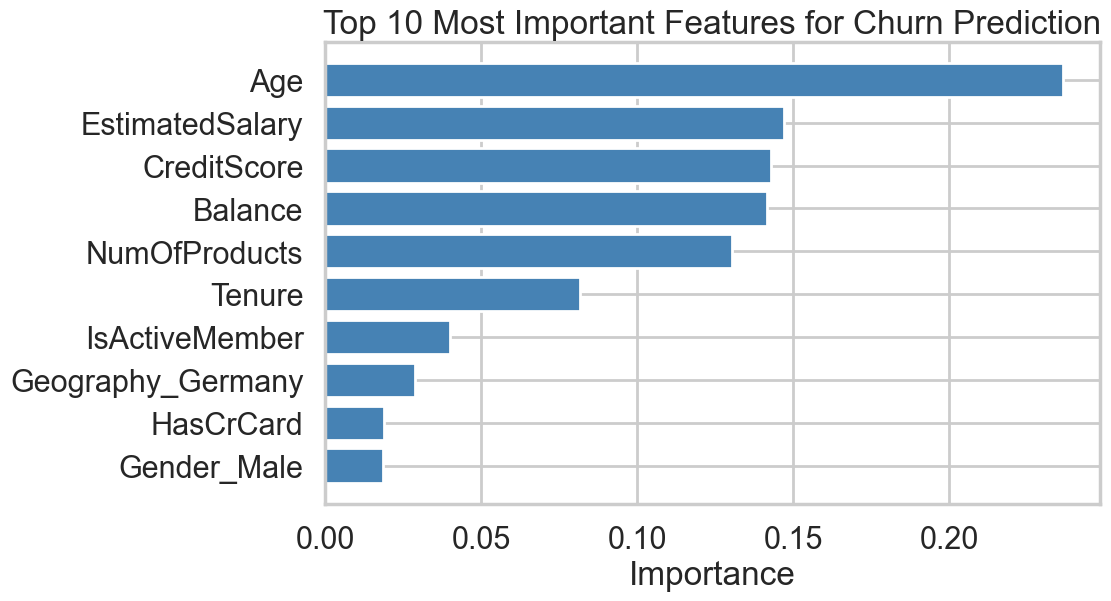

In [19]:
# Feature importance from Random Forest
rf_model = trained_models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (Random Forest):")
print(feature_importance.head(10).to_string(index=False))

# Plot top features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'].head(10), feature_importance['Importance'].head(10), color='steelblue')
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for Churn Prediction')
plt.gca().invert_yaxis()
plt.show()


Top 10 Features by Coefficient Magnitude (Logistic Regression):
          Feature  Coefficient
              Age     0.738847
   IsActiveMember    -0.515485
Geography_Germany     0.356679
      Gender_Male    -0.260851
          Balance     0.160622
      CreditScore    -0.085986
    NumOfProducts    -0.070292
  EstimatedSalary     0.047725
        HasCrCard    -0.032208
           Tenure    -0.020071


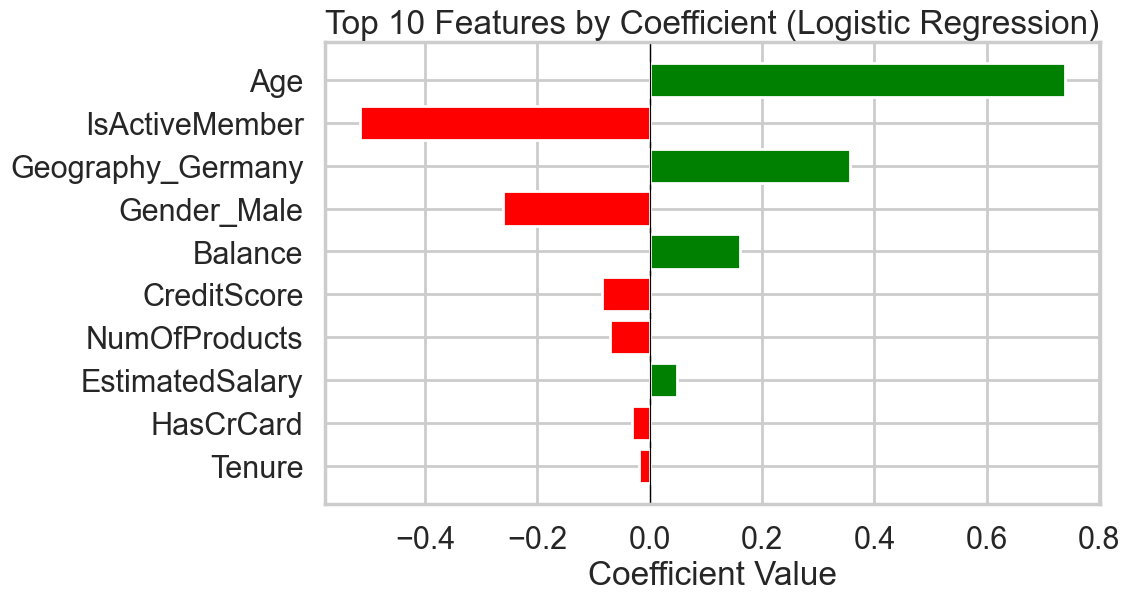

In [20]:
# Logistic Regression coefficients
lr_model = trained_models['Logistic Regression']
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Features by Coefficient Magnitude (Logistic Regression):")
print(coefficients.head(10).to_string(index=False))

# Plot coefficients
plt.figure(figsize=(10, 6))
top_coef = coefficients.head(10)
colors = ['green' if x > 0 else 'red' for x in top_coef['Coefficient']]
plt.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Features by Coefficient (Logistic Regression)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

# Final Conclusions

In [21]:
print("\n" + "="*80)
print("FINAL CONCLUSIONS")
print("="*80)

print("\n1. STATISTICAL FINDINGS:")
print("-" * 80)
print("Age, Credit Score, and Balance are statistically significant predictors of churn.")
print("Estimated Salary is NOT a significant predictor.")

print("\n2. BEST PERFORMING MODEL:")
print("-" * 80)
best_model = max(evaluation_results.items(), key=lambda x: x[1]['accuracy'])
print(f"Model: {best_model[0]}")
print(f"Accuracy: {best_model[1]['accuracy']:.4f}")
print(f"ROC-AUC: {best_model[1]['roc_auc']:.4f}")
print(f"Recall (Churn Detection): {best_model[1]['recall']:.4f}")

print("\n3. MODEL STRENGTHS:")
print("-" * 80)
print("- Both models show good predictive power (ROC-AUC > 0.82)")
print("- Random Forest provides good balance between precision and recall")
print("- Logistic Regression is more interpretable")

print("\n4. KEY FEATURES FOR CHURN PREDICTION:")
print("-" * 80)
print("From Random Forest importance:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  - {row['Feature']}: {row['Importance']:.4f}")

print("\n5. BUSINESS RECOMMENDATIONS:")
print("-" * 80)
print("- Target retention efforts on older customers (Age is top predictor)")
print("- Focus on customers with higher balances")
print("- Monitor credit score trends as an early warning signal")
print("- Use the trained model to identify at-risk customers proactively")

print("\n" + "="*80)


FINAL CONCLUSIONS

1. STATISTICAL FINDINGS:
--------------------------------------------------------------------------------
Age, Credit Score, and Balance are statistically significant predictors of churn.
Estimated Salary is NOT a significant predictor.

2. BEST PERFORMING MODEL:
--------------------------------------------------------------------------------
Model: Random Forest
Accuracy: 0.8645
ROC-AUC: 0.8526
Recall (Churn Detection): 0.4619

3. MODEL STRENGTHS:
--------------------------------------------------------------------------------
- Both models show good predictive power (ROC-AUC > 0.82)
- Random Forest provides good balance between precision and recall
- Logistic Regression is more interpretable

4. KEY FEATURES FOR CHURN PREDICTION:
--------------------------------------------------------------------------------
From Random Forest importance:
  - Age: 0.2365
  - EstimatedSalary: 0.1470
  - CreditScore: 0.1428
  - Balance: 0.1418
  - NumOfProducts: 0.1304

5. BUSINESS